In [1]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

## 2.1 Load & Inspect

- عدد الصفوف: 187,531 وعدد الأعمدة: 21
- أغلب الأعمدة نوعها نصي (str)، وبعضها لازم يتحول لأرقام لاحقًا (مثل Amount, Carpet Area, Bathroom)
- الأعمدة الأكثر فراغًا: Plot Area و Dimensions (100% فاضية)، يليهم Society (58%) و Super Area (57%) و Car Parking (55%)

In [5]:
## 2.2 Exploratory Data Analysis (EDA)

In [6]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(177847, 22)

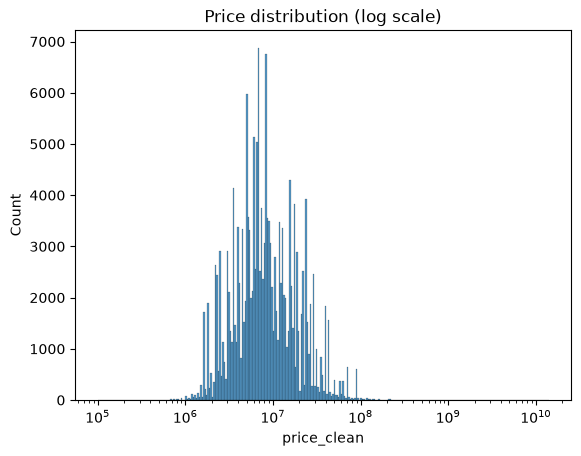

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

معظم الأسعار مركزة حوالي قيمة معينة، والتوزيع بعد استخدام log scale بقى شبه متماثل (طبيعي)، بينما قبل الـ log كان منحرف جدًا لليمين بسبب وجود شقق غالية جدًا.

In [8]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        return None
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["carpet_area_sqft"].describe()

count     96856.000000
mean       1288.106765
std        3198.050010
min           1.000000
25%         840.000000
50%        1093.000000
75%        1525.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

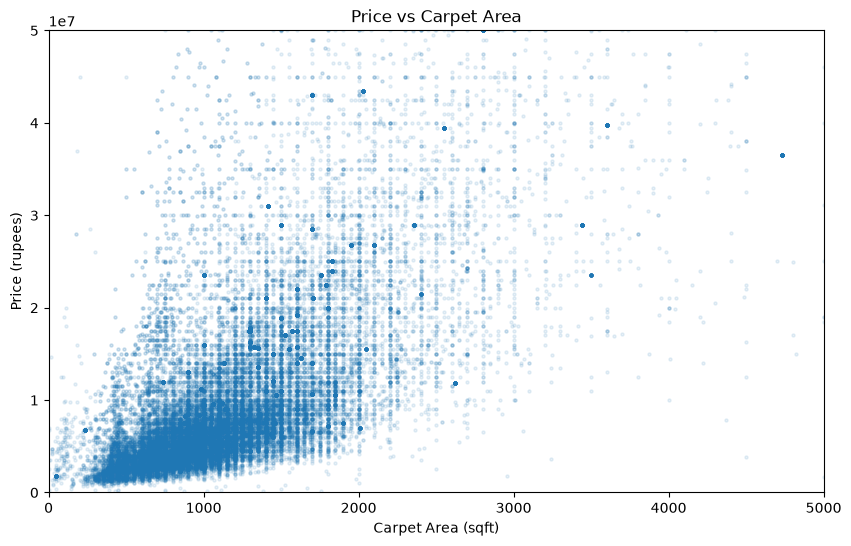

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df["carpet_area_sqft"], df["price_clean"], alpha=0.1, s=5)
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (rupees)")
plt.title("Price vs Carpet Area")
plt.xlim(0, 5000)
plt.ylim(0, 5e7)
plt.show()

فيه علاقة طردية واضحة بين مساحة الشقة والسعر: كل ما المساحة تزيد، السعر يزيد معاها. التركيز الأكبر للبيانات في نطاق مساحة 500-1500 sqft وسعر يصل لحد 15 مليون روبية تقريبًا.

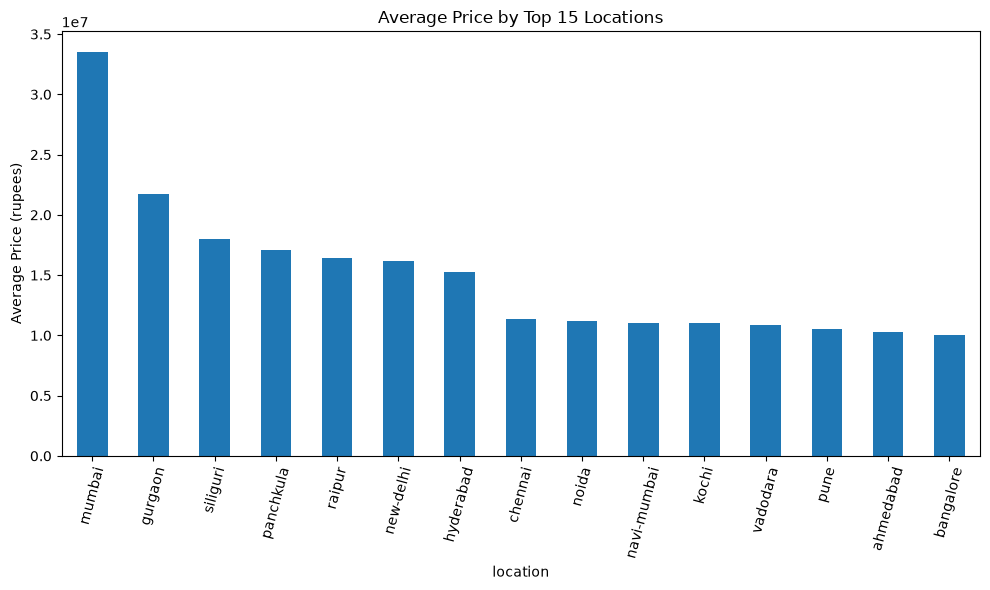

In [10]:
top_locations = df.groupby("location")["price_clean"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_locations.plot(kind="bar")
plt.ylabel("Average Price (rupees)")
plt.title("Average Price by Top 15 Locations")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

بعض المناطق أسعارها أعلى بكتير من غيرها، وده منطقي لأن الموقع من أهم العوامل المؤثرة على سعر العقار.

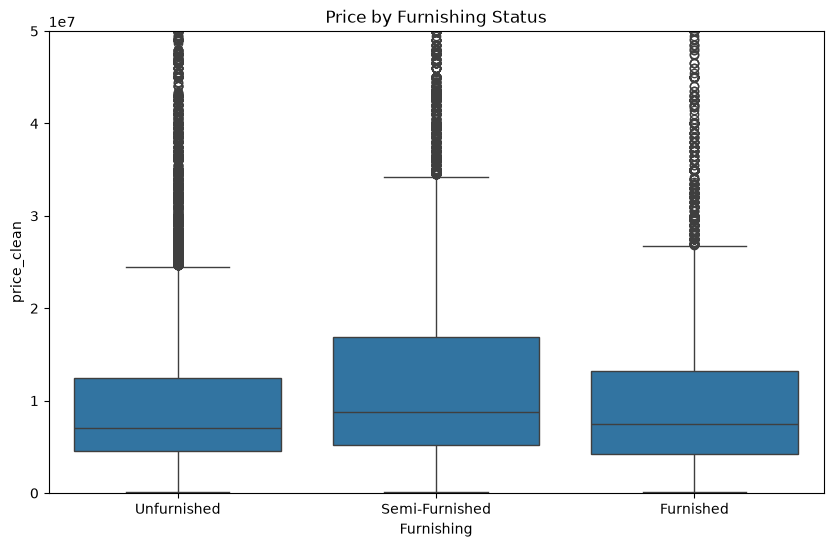

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Furnishing", y="price_clean", data=df)
plt.title("Price by Furnishing Status")
plt.ylim(0, 5e7)
plt.show()

لوحظ أن الشقق "Semi-Furnished" لها متوسط سعر أعلى قليلاً من "Furnished" و"Unfurnished"، وهذا قد يكون بسبب عوامل أخرى مرتبطة (مثل المنطقة أو المساحة) وليس التأثيث وحده.

## 2.3 Cleaning & Feature Engineering

In [12]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    try:
        return int(x.split("out")[0].strip())
    except (ValueError, IndexError):
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()

count    170898.000000
mean          4.499029
std           4.701323
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

In [13]:
def parse_numeric(x):
    if pd.isna(x):
        return None
    if isinstance(x, (int, float)):
        return x
    x = str(x).strip().lower()
    try:
        return float(x)
    except ValueError:
        import re
        match = re.search(r'\d+', x)
        if match:
            return float(match.group())
        return None

df["bathroom_num"] = df["Bathroom"].apply(parse_numeric)
df["balcony_num"] = df["Balcony"].apply(parse_numeric)
df["car_parking_num"] = df["Car Parking"].apply(parse_numeric)

df["bathroom_num"] = df["bathroom_num"].fillna(df["bathroom_num"].median())
df["balcony_num"] = df["balcony_num"].fillna(0)
df["car_parking_num"] = df["car_parking_num"].fillna(0)

df[["bathroom_num", "balcony_num", "car_parking_num"]].describe()

,bathroom_num,balcony_num,car_parking_num
count,177847.000000,177847.000000,177847.000000
mean,2.447407,1.479266,1.845946
std,0.856242,1.208510,21.550934
min,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000
75%,3.000000,2.000000,1.000000
max,10.000000,10.000000,999.000000


In [14]:
top_n_locations = df["location"].value_counts().head(50).index
df["location_grouped"] = df["location"].apply(lambda x: x if x in top_n_locations else "other")
df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

In [15]:
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area"])
df.shape

(177847, 23)

In [16]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)

before = df.shape[0]
df = df[(df["price_per_sqft"] >= lower) | (df["price_per_sqft"].isna())]
df = df[(df["price_per_sqft"] <= upper) | (df["price_per_sqft"].isna())]
after = df.shape[0]

print(f"Removed {before - after} rows as outliers")
df.shape

Removed 1593 rows as outliers


(176254, 24)

تم تنظيف البيانات بالكامل: تحويل السعر والمساحة والدور لأرقام، معالجة القيم الفارغة في الحمام/البلكونة/الباركينج، تجميع المناطق عالية التنوع في فئة "أخرى"، حذف الأعمدة غير المفيدة، وإزالة القيم الشاذة بناءً على السعر لكل قدم مربع.

## 2.4 Build a Pipeline & Train

In [17]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom_num", "balcony_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

df_model = df.dropna(subset=["carpet_area_sqft", "price_clean"])
df_model.shape

(95263, 24)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df_model[numeric_features + categorical_features]
y = df_model["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (76210, 9)
Test shape: (19053, 9)


In [19]:
model_lr = Pipeline([("prep", preprocessor),
                      ("reg", LinearRegression())])
model_lr.fit(X_train, y_train)
print("Linear Regression trained successfully")

Linear Regression trained successfully


In [20]:
model_rf = Pipeline([("prep", preprocessor),
                      ("reg", RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42))])
model_rf.fit(X_train, y_train)
print("Random Forest trained successfully")

Random Forest trained successfully


In [21]:
model_lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom_num',...,'Transaction', 'Ownership','facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

## 2.5 Evaluate

In [22]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

for name, model in [("Linear Regression", model_lr), ("Random Forest", model_rf)]:
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"--- {name} ---")
    print(f"MAE : {mae:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R²  : {r2:.4f}")
    print()

--- Linear Regression ---
MAE : 4,171,524
RMSE: 6,659,685
R²  : 0.7494

--- Random Forest ---
MAE : 1,146,884
RMSE: 3,565,063
R²  : 0.9282



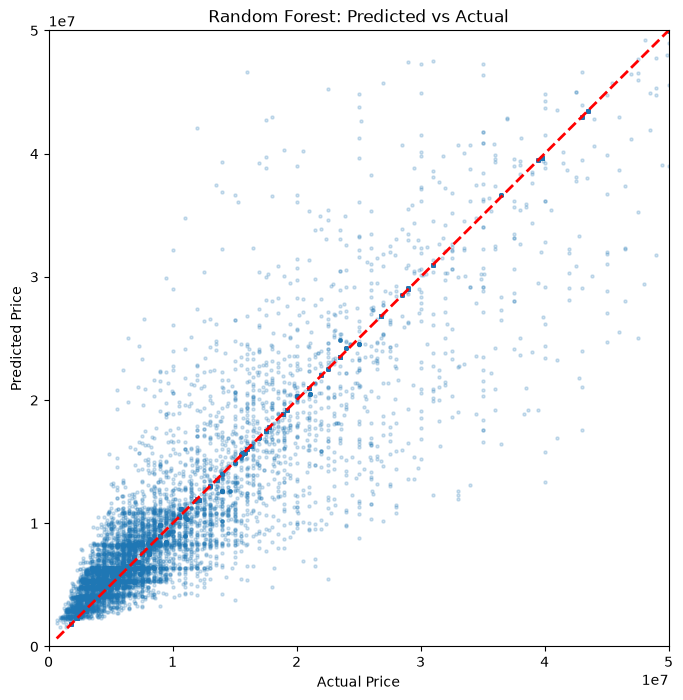

In [23]:
pred_rf = model_rf.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred_rf, alpha=0.2, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual")
plt.xlim(0, 5e7)
plt.ylim(0, 5e7)
plt.show()

### مقارنة الموديلات

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 4,171,524 | 6,659,685 | 0.7494 |
| Random Forest | 1,146,884 | 3,565,063 | 0.9282 |

**الموديل المختار: Random Forest**

بيحقق أداء أفضل بشكل كبير من Linear Regression على كل المقاييس الثلاثة. الـ R² يوضح أن الموديل يفسر حوالي 93% من التباين في الأسعار، مقارنة بـ 75% فقط في الموديل الخطي. هذا منطقي لأن العلاقة بين خصائص العقار والسعر ليست خطية بالضرورة (مثل تأثير المنطقة والتفاعل بين المساحة والموقع)، والـ Random Forest قادر على التقاط هذه العلاقات غير الخطية والتفاعلات المعقدة بين المتغيرات بشكل أفضل من النموذج الخطي البسيط.

## 2.6 Export the Model

In [24]:
import joblib

joblib.dump(model_rf, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [5228435.23958388]


In [25]:
import json

locations_list = sorted(df["location_grouped"].unique().tolist())
json.dump(locations_list, open("locations.json", "w"))
print(f"Saved {len(locations_list)} locations")

Saved 51 locations


In [26]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0
